<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds


## 1. Data, Plotting, and Train/Test Sets (2 pts)
-----
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [1]:
library(class)
library(tidyverse)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
names(diamonds)

[1] "carat"   "cut"     "color"   "clarity" "depth"   "table"   "price"  
 [8] "x"       "y"       "z"

In [3]:
di <-diamonds

In [4]:

di <- di |>
  mutate(price_bin = as.factor(if_else(price > mean(price), 1, 0)))

In [5]:
di <- di|>
    select( carat, depth, table, x, y, price_bin)


In [6]:
print(di)

# A tibble: 53,940 × 6
   carat depth table     x     y price_bin
   <dbl> <dbl> <dbl> <dbl> <dbl> <fct>    
 1  0.23  61.5    55  3.95  3.98 0        
 2  0.21  59.8    61  3.89  3.84 0        
 3  0.23  56.9    65  4.05  4.07 0        
 4  0.29  62.4    58  4.2   4.23 0        
 5  0.31  63.3    58  4.34  4.35 0        
 6  0.24  62.8    57  3.94  3.96 0        
 7  0.24  62.3    57  3.95  3.98 0        
 8  0.26  61.9    55  4.07  4.11 0        
 9  0.22  65.1    61  3.87  3.78 0        
10  0.23  59.4    61  4     4.05 0        
# ℹ 53,930 more rows


In [7]:
dim(di)

[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

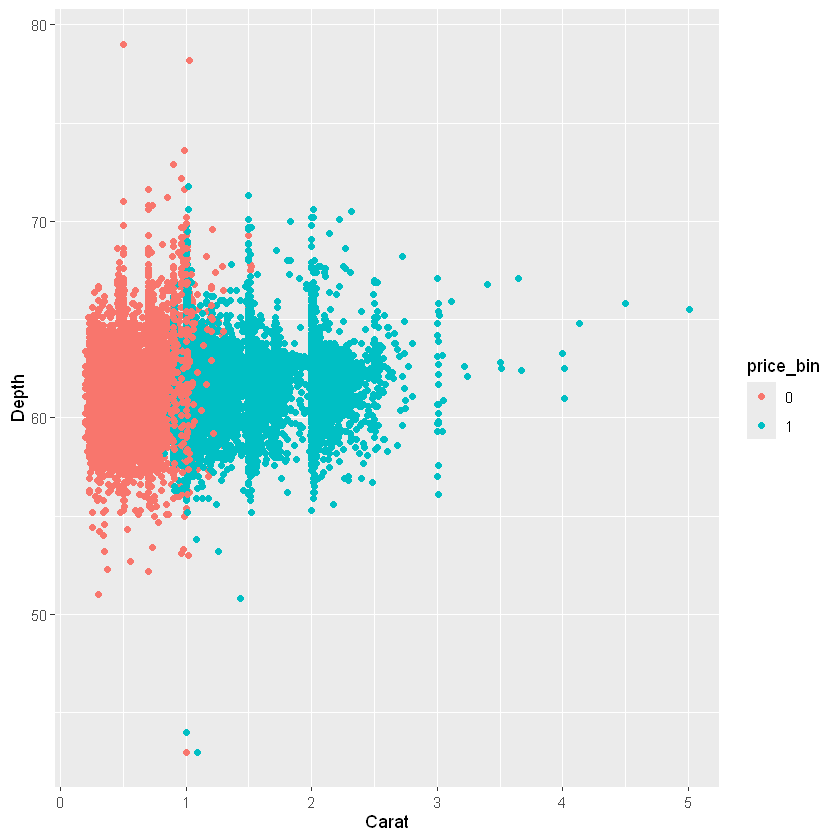

In [8]:
# INSERT CODE HERE
ggplot(di, aes(x=carat, y=depth, color = price_bin)) + 
    geom_point() +
    scale_x_continuous(name = 'Carat') +
    scale_y_continuous(name = 'Depth')

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> kNN should perform moderately well — carat shows clear separation between price classes, though there is overlap at low carat values that will reduce accuracy. Carat provides far more information than depth, as depth shows almost no difference between the two price groups."
> THe knn should perform well as there is a clear separation between class groups with little overlap aside from at the lower, 1 carat range. So, there could be less accuracy for ther lower carat differentations but overall I expect the knn to perform well. Carats will give us the most informatio as the classes are visibly split along the x-axis for Carat.

### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [9]:
set.seed(2023)


test <- sample(1:nrow(di), size = 0.3 * nrow(di))
train <- di[-test, c("carat", "depth", "table", "x", "y")]

train_labels <- di[-test, ]$price_bin 

test_pred <- di[test, c("carat", "depth", "table", "x", "y")]
test_labels <- di[test, ]$price_bin

In [10]:
print(train)
head(train, n=3)
dim(train)

# A tibble: 37,758 × 5
   carat depth table     x     y
   <dbl> <dbl> <dbl> <dbl> <dbl>
 1  0.23  61.5    55  3.95  3.98
 2  0.23  56.9    65  4.05  4.07
 3  0.29  62.4    58  4.2   4.23
 4  0.31  63.3    58  4.34  4.35
 5  0.24  62.8    57  3.94  3.96
 6  0.24  62.3    57  3.95  3.98
 7  0.26  61.9    55  4.07  4.11
 8  0.22  65.1    61  3.87  3.78
 9  0.23  59.4    61  4     4.05
10  0.23  62.8    56  3.93  3.9 
# ℹ 37,748 more rows


carat,depth,table,x,y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98
0.23,56.9,65,4.05,4.07
0.29,62.4,58,4.20,4.23


[1] 37758     5

In [11]:
print(test_pred)
head(test_pred, n=3)
dim(test_pred)

# A tibble: 16,182 × 5
   carat depth table     x     y
   <dbl> <dbl> <dbl> <dbl> <dbl>
 1  1.22  62.3  56    6.81  6.84
 2  1.57  62.3  56    7.48  7.41
 3  1.11  62.4  57.7  6.57  6.64
 4  0.42  60.6  57    4.82  4.85
 5  0.32  62.6  55    4.39  4.36
 6  0.9   62.7  58    6.06  6.15
 7  1.09  62.5  57    6.56  6.58
 8  0.53  62.2  56    5.16  5.2 
 9  0.23  60.4  59    4     3.95
10  0.55  61.3  54    5.28  5.36
# ℹ 16,172 more rows


carat,depth,table,x,y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.22,62.3,56.0,6.81,6.84
1.57,62.3,56.0,7.48,7.41
1.11,62.4,57.7,6.57,6.64


[1] 16182     5

## 2: KNN (3 points)
----
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [12]:
set.seed(2023)
knn <- knn (train = train, test = test_pred, cl = train_labels, k = 3)

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [13]:
confusion_matrix <- table(Predicted = knn, Actual = test_labels)
confusion_matrix

         Actual
Predicted    0    1
        0 9728  391
        1  518 5545

In [14]:
test_err <- 1- (mean(knn ==test_labels)) #test error
test_err

[1] 0.05617353

How did your model perform?
> The modeled performed well, there was a 5.6% proportion of incorrect classification meaning it has high accuracy.

Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [15]:
head(diamonds)

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


In [16]:
diamonds <- diamonds |>
  mutate(price_bin = as.factor(if_else(price > mean(price), 1, 0)),
         cut = as.numeric(cut),
         color = as.numeric(color),
         clarity = as.numeric(clarity))
str(train_all)

ERROR: Error: object 'train_all' not found


In [17]:
set.seed(2023)

diamonds <- diamonds |>
  mutate(price_bin = as.factor(if_else(price > mean(price), 1, 0)))

test_all <- sample(1:nrow(diamonds), size = 0.3 * nrow(diamonds))
train_all <- diamonds[-test, c("color","cut","carat", "depth", "table", "x", "y","z")]


train_all_labels <- diamonds[-test, ]$price_bin 



In [18]:
test_pred_all <- diamonds[test_all, c("color","cut","carat", "depth", "table", "x", "y","z")]
test_labels_all <- diamonds[test_all, ]$price_bin

In [19]:
set.seed(2023)
knn_all <- knn (train = train_all, test = test_pred_all, cl = train_all_labels, k = 3)

In [20]:
confusion_matrix <- table(Predicted = knn_all, Actual = test_labels_all)
confusion_matrix

         Actual
Predicted    0    1
        0 9760  379
        1  486 5557

In [21]:
test_err_all <- 1- (mean(knn_all == test_labels_all)) #test error
test_err_all

[1] 0.05345446

Did your model predictions improve?
> THe model had a slight improvement from 5.6% to a lowered 5.3% proportion of incorrect classification. So, the model still has high accuracy but including all the variables only improved the model very slightly


# 3: for loop (3 points)
----

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [22]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [26]:
for (k in seq(1:30)) {
  knn_k <- knn(train = train_all, test = test_pred_all, cl = train_all_labels, k = k)
  
  conf_df <- data.frame(Predicted = knn_k, Actual = test_labels_all)
  
  output$error[k] <- mean(conf_df$Predicted != conf_df$Actual)
}

head(output)


,k,error
,<int>,<dbl>
1,1,0.06062291
2,2,0.06377456
3,3,0.05339266
4,4,0.05499938
5,5,0.05178593
6,6,0.05240391


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

geom_smooth: na.rm = FALSE, orientation = NA, se = FALSE
stat_smooth: na.rm = FALSE, orientation = NA, se = FALSE
position_identity 

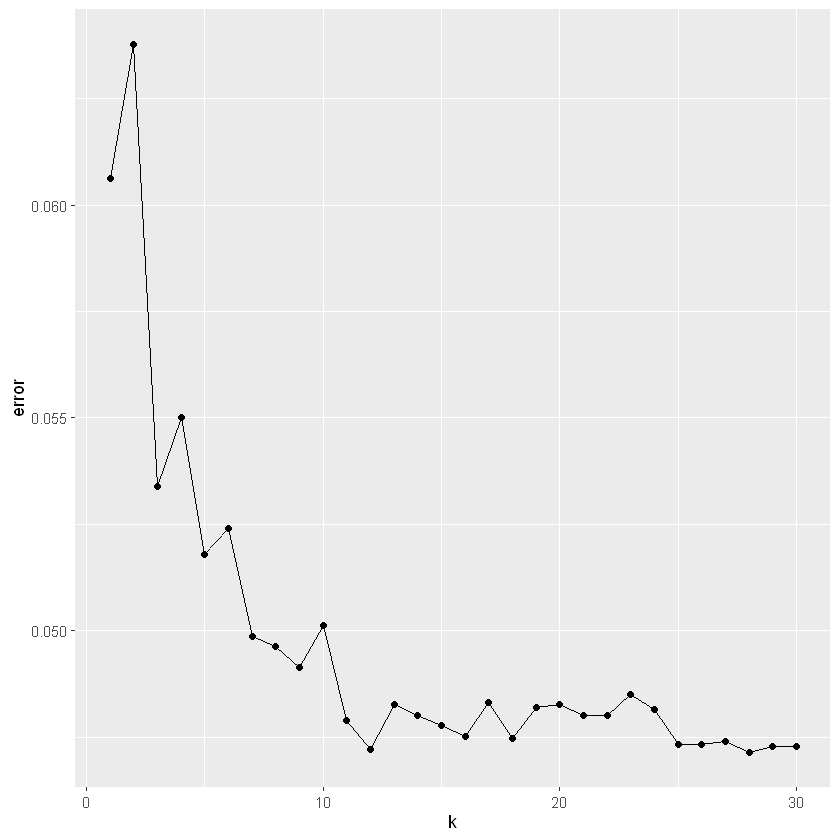

In [28]:
ggplot(output, aes(x = k, y = error)) +
  geom_line() +
  geom_point()
 geom_smooth(se = FALSE) 

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> I would select k= 28 to be the best value of k as it reports the lowest error. 
> *


# 4: Standardizing predictors (2)
-----

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [35]:
set.seed(2023)
 
diamonds_scaled <- diamonds |>
  mutate(carat = scale(carat, center = TRUE, scale = TRUE),
         depth = scale(depth, center = TRUE, scale = TRUE))


In [37]:
#re-reun model after scale
test_inds <- sample(1:nrow(diamonds_scaled), size = 0.3 * nrow(diamonds_scaled))

train_scaled <- diamonds_scaled[-test_inds, c("carat", "depth")]
train_scaled_labels <- diamonds_scaled[-test_inds, ]$price_bin
test_scaled <- diamonds_scaled[test_inds, c("carat", "depth")]
test_scaled_labels <- diamonds_scaled[test_inds, ]$price_bin

In [38]:
#knn 
knn_scaled <- knn(train = train_scaled, test = test_scaled, cl = train_scaled_labels, k = 28)


In [39]:
#confusion matrix
table(Predicted = knn_scaled, Actual = test_scaled_labels)
#error rate
1 - mean(knn_scaled == test_scaled_labels)

         Actual
Predicted    0    1
        0 9719  293
        1  530 5640

[1] 0.05085898

What impact did rescaling the data have on your error rate?
> Re-scaling the model provided the best model performance with the lowest error rate 5.1% with k = 28 in comparison to the intial 5.6% with k=3. 
>
> *


**DUE:** 5pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>
